# Demo: Multiple Linear Regression

Context: We study how **students' GPA** depends on:

- `StudyHours` = weekly hours of study  
- `SleepHours` = average sleep hours per night  

A sample sample is drawed from a population which is generated by the following true population model:

$\text{GPA} = \beta_0 
           + \beta_1 \cdot \text{StudyHours}
           + \beta_2 \cdot \text{StudyHours}^2
           + \beta_3 \cdot \text{SleepHours}
           + \beta_4 (\text{StudyHours} \times \text{SleepHours})
           + \varepsilon$

In [1]:
# If statsmodels is not installed in your environment, run:
# %pip install statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm

## Step 1: Create the population

Original N: 100000 Valid N: 99894
GPA mean: 3.0471700284547376 min: 1.6951969124355013 max: 3.9988785313792867


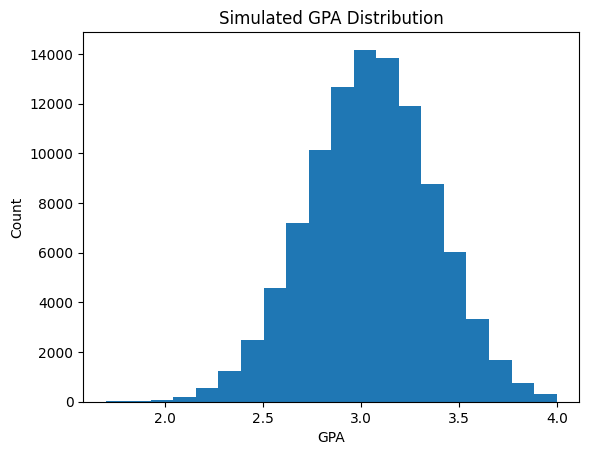

In [3]:
# for reproducibility
np.random.seed(3101)

# Population size
N = 100_000

# -------------------------
# StudyHours ~ Normal(mean, std), truncated to [0, 30]
# -------------------------
mean_study = 12
std_study = 4
min_study = 0
max_study = 30

pool_study = np.random.normal(mean_study, std_study, 5 * N)
valid_study = pool_study[(pool_study >= min_study) & (pool_study <= max_study)]

while len(valid_study) < N:
    pool_study = np.random.normal(mean_study, std_study, 5 * N)
    valid_study = np.concatenate([
        valid_study,
        pool_study[(pool_study >= min_study) & (pool_study <= max_study)]
    ])

StudyHours_pop = valid_study[:N]

# -------------------------
# SleepHours ~ Normal(mean, std), truncated to [4, 9]
# -------------------------
mean_sleep = 7.0
std_sleep = 1.0
min_sleep = 4
max_sleep = 9

pool_sleep = np.random.normal(mean_sleep, std_sleep, 5 * N)
valid_sleep = pool_sleep[(pool_sleep >= min_sleep) & (pool_sleep <= max_sleep)]

while len(valid_sleep) < N:
    pool_sleep = np.random.normal(mean_sleep, std_sleep, 5 * N)
    valid_sleep = np.concatenate([
        valid_sleep,
        pool_sleep[(pool_sleep >= min_sleep) & (pool_sleep <= max_sleep)]
    ])

SleepHours_pop = valid_sleep[:N]

# --- True coefficients (re-tuned for realistic GPA) ---
beta_0 = 1.6          # baseline GPA
beta_1 = 0.05         # StudyHours (positive, but modest)
beta_2 = -0.002       # StudyHours^2 (diminishing returns)
beta_3 = 0.12         # SleepHours (more sleep, higher GPA)
beta_4 = 0.004        # interaction: sleep makes studying more effective

# Random error term (slightly larger spread)
sigma = 0.25
epsilon = np.random.normal(0, sigma, size=N)

# Generate GPA values (unbounded)
GPA_pop = (
    beta_0
    + beta_1 * StudyHours_pop
    + beta_2 * StudyHours_pop**2
    + beta_3 * SleepHours_pop
    + beta_4 * StudyHours_pop * SleepHours_pop
    + epsilon
)

# Keep only realistic GPAs in [0, 4]
valid_mask = (GPA_pop >= 0) & (GPA_pop <= 4)

GPA_pop_valid    = GPA_pop[valid_mask]
Study_valid      = StudyHours_pop[valid_mask]
Sleep_valid      = SleepHours_pop[valid_mask]

print("Original N:", N, "Valid N:", len(GPA_pop_valid))
print("GPA mean:", GPA_pop_valid.mean(),
      "min:", GPA_pop_valid.min(),
      "max:", GPA_pop_valid.max())

# Build population sampleFrame
pop = pd.DataFrame({
    "GPA": GPA_pop_valid,
    "StudyHours": Study_valid,
    "SleepHours": Sleep_valid
})

# Quick check: histogram
plt.hist(pop["GPA"], bins=20)
plt.xlabel("GPA")
plt.ylabel("Count")
plt.title("Simulated GPA Distribution")
plt.show()

In [4]:
# Sample size
n = 200

sample = pop.sample(n=n, replace=False, random_state=2025)
sample.head()

,GPA,StudyHours,SleepHours
71425,3.216069,15.779642,7.511928
85302,3.029870,14.551492,5.723535
35145,2.853764,4.115316,7.401141
64086,3.114123,18.292656,6.222005
62355,2.378654,10.772988,6.233099


In [5]:
print(sample.head())

            GPA  StudyHours  SleepHours
71425  3.216069   15.779642    7.511928
85302  3.029870   14.551492    5.723535
35145  2.853764    4.115316    7.401141
64086  3.114123   18.292656    6.222005
62355  2.378654   10.772988    6.233099


## Step 2: Exploratory Plots

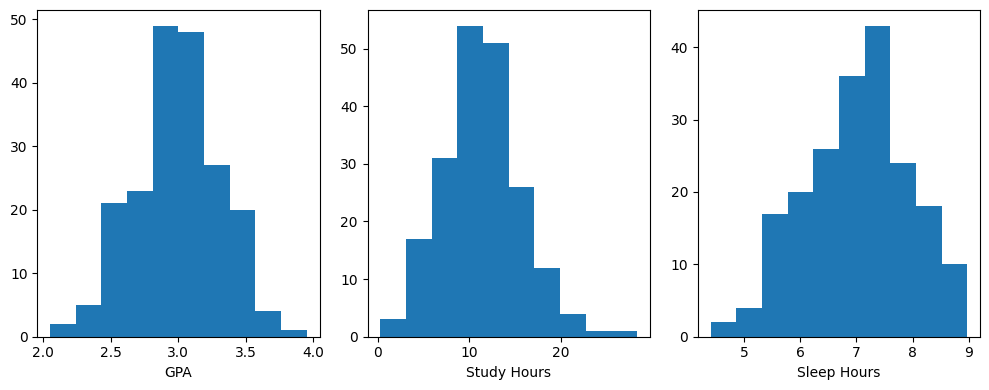

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].hist(sample["GPA"])
axes[0].set_xlabel("GPA")

axes[1].hist(sample["StudyHours"])
axes[1].set_xlabel("Study Hours")

axes[2].hist(sample["SleepHours"])
axes[2].set_xlabel("Sleep Hours")

plt.tight_layout()
plt.show()

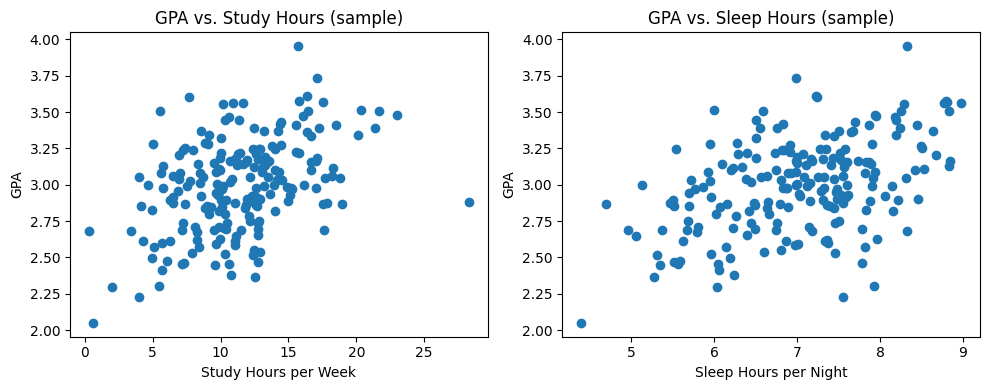

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# GPA vs StudyHours
axes[0].scatter(sample["StudyHours"], sample["GPA"])
axes[0].set_xlabel("Study Hours per Week")
axes[0].set_ylabel("GPA")
axes[0].set_title("GPA vs. Study Hours (sample)")

# GPA vs SleepHours
axes[1].scatter(sample["SleepHours"], sample["GPA"])
axes[1].set_xlabel("Sleep Hours per Night")
axes[1].set_ylabel("GPA")
axes[1].set_title("GPA vs. Sleep Hours (sample)")

plt.tight_layout()
plt.show()

Observations:

## Step 3: Model 1 – Linear Effects Only

We start with a simple multiple linear regression model **without** quadratic or interaction terms:

$\text{GPA} = \beta_0 + \beta_1 \cdot \text{StudyHours}
            + \beta_2 \cdot \text{SleepHours} + \varepsilon$

In [8]:
model1 = sm.ols("GPA ~ StudyHours + SleepHours", data=sample).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     61.61
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           1.66e-21
Time:                        17:14:38   Log-Likelihood:                -7.3094
No. Observations:                 200   AIC:                             20.62
Df Residuals:                     197   BIC:                             30.51
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5615      0.143     10.956      0.000       1.280       1.843
StudyHours     0.0317      0.004      7.504      0.000       0.023       0.040
SleepHours     0.1531      0.019      8.028      0.000       0.116       0.191
==============================================================================
Omnibus:                        0.077   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.962   Jarque-Bera (JB):                0.199
Skew:                           0.025   Prob(JB):                        0.905
Kurtosis:                       2.854   Cond. No.                         112.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Step 4: Model 2 – Add a Quadratic Term for StudyHours

We now allow for a nonlinear effect of StudyHours by adding a squared term:

$\text{StudyHours\_sq} = \text{StudyHours}^2$

$\text{GPA} = \beta_0 + \beta_1 \cdot \text{StudyHours}
            + \beta_2 \cdot \text{StudyHours}^2
            + \beta_3 \cdot \text{SleepHours} + \varepsilon
$

In [9]:
# Create the quadratic term
sample["StudyHours_sq"] = sample["StudyHours"] ** 2

model2 = sm.ols("GPA ~ StudyHours + StudyHours_sq + SleepHours", data=sample).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     43.56
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           1.29e-21
Time:                        17:14:38   Log-Likelihood:                -4.7978
No. Observations:                 200   AIC:                             17.60
Df Residuals:                     196   BIC:                             30.79
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.3782      0.163      8.443

Observations:

## Step 5: Model 3 – Quadratic + Interaction

Finally, we allow the effect of StudyHours to depend on SleepHours by adding an interaction term:

$\text{GPA} = \beta_0 + \beta_1 \cdot \text{StudyHours}
            + \beta_2 \cdot \text{StudyHours}^2
            + \beta_3 \cdot \text{SleepHours}
            + \beta_4 (\text{StudyHours} \times \text{SleepHours}) + \varepsilon
$

In [10]:
model3 = sm.ols( "GPA ~ StudyHours + StudyHours_sq + SleepHours + StudyHours:SleepHours", data=sample).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     32.51
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           9.30e-21
Time:                        17:14:38   Log-Likelihood:                -4.7977
No. Observations:                 200   AIC:                             19.60
Df Residuals:                     195   BIC:                             36.09
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.38

## Step 6: Compare the Models

We compare **Model 1**, **Model 2**, and **Model 3** on $R^2$ and adjusted $R^2$.

Questions for interpretation:

1. How do model fit measures change across models?  
2. Are the quadratic and interaction terms statistically significant?  
3. Which model best approximates the **true** population model we specified?  
4. What do the coefficients tell us about:
   - diminishing returns to study time?  
   - the role of sleep in making study time more effective?


In [11]:
comparison = pd.DataFrame({
    "Model": ["Model 1: Linear", "Model 2: + Quadratic", "Model 3: + Quadratic + Interaction"],
    "R2": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R2": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj]
})
comparison

,Model,R2,Adj_R2
0,Model 1: Linear,0.384788,0.378543
1,Model 2: + Quadratic,0.400048,0.390865
2,Model 3: + Quadratic + Interaction,0.400048,0.387741
